# I. Analyse des échantillons

Dans un premier temps, nous allons analyser les échantillons à notre disposition, en comptant le nombre de polygones et de pixels par classe d'occupation du sol.  
Nous calculerons ensuite l'indice ARI de notre image pour chaque date et pour chaque strate.

## 1. Nombre d'échantillons

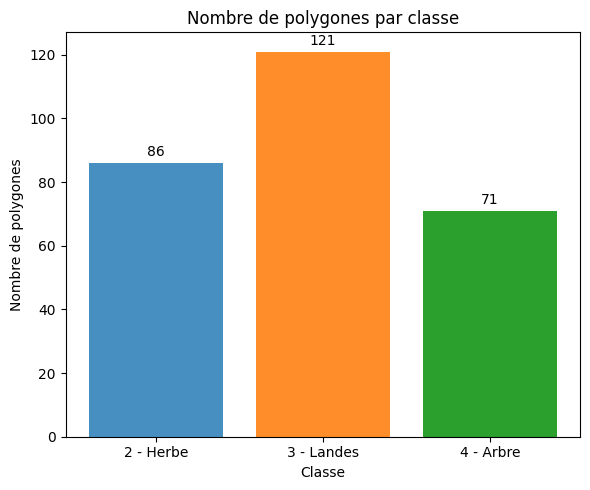

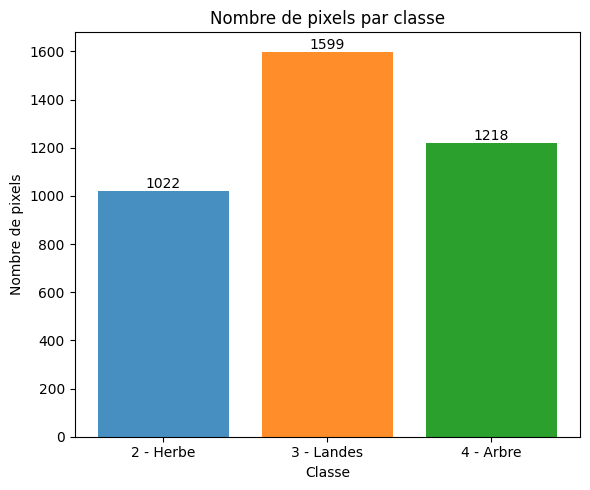

In [1]:
import sys
sys.path.append("/home/onyxia/work")

import geopandas as gpd
import my_function as mf

BASE = "/home/onyxia/work"
DATA = f"{BASE}/data/projet_eval"
RES = mf.make_dir(f"{BASE}","results")
FIG = mf.make_dir(f"{RES}","figure")


# -------------------------------
# PARAMETRES
# -------------------------------

b03 = f"{DATA}/bretagne_23-24_B03.tif"
b05 = f"{DATA}/bretagne_23-24_B05.tif"
shp = f"{DATA}/PI_strates_bretagne_32630.shp"

dates = [
    "2024-07-19",
    "2024-06-07",
    "2024-04-18",
    "2024-01-19",
    "2023-10-08"
]

classe_nom = {
    1: "Sol Nu",
    2: "Herbe",
    3: "Landes",
    4: "Arbre"
}

ordre = [2, 3, 4]


# -------------------------------
# HISTO POLY
# -------------------------------

gdf = gpd.read_file(shp)

mf.plot_polygon_histogram(
    gdf=gdf,
    classe_col="strate",
    classe_labels=classe_nom,
    out_file=f"{FIG}/diag_baton_nb_poly_by_class.png"
)


# -------------------------------
# RASTERISATION STRATES
# -------------------------------

roi = mf.rasterization_in_memory(
    shp,
    b03,
    "strate"
)


# -------------------------------
# HISTO PIXELS
# -------------------------------

counts = mf.count_pixels_by_class(roi)

mf.plot_pixel_histogram(
    counts,
    classe_nom,
    f"{FIG}/diag_baton_nb_pix_by_class.png"
)

On peut donc observer que la classe Sol nu est inexistante dans nos échantillons.  
La classe la plus représentée (autant au niveau du nombre de polygones que de pixels) est celle des Landes.  
Les classes Herbe et Arbre sont relativement équivalente en nombre, on peut de tout de même noter qu'il y a plus de polygones de classe Herbe alors qu'il y a plus de pixels de classe Arbre.

## 2. Indice ARI

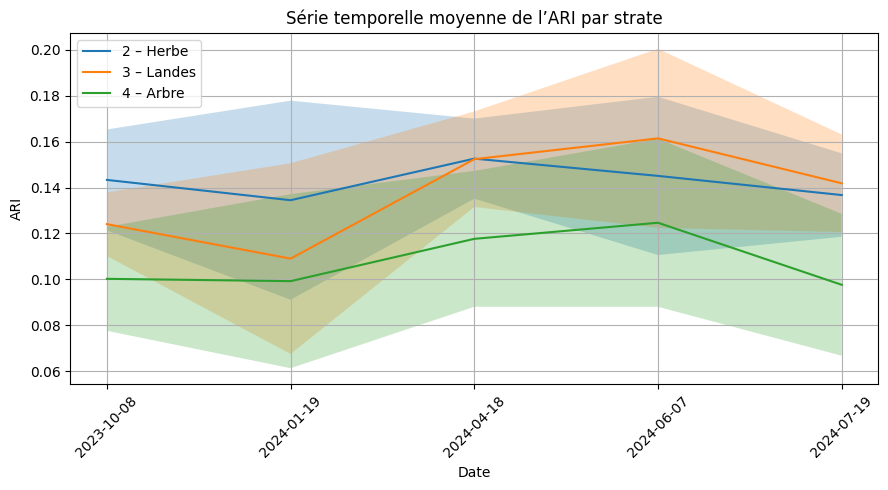

In [2]:
# -------------------------------
# STACK ARI
# -------------------------------

ari_stack = mf.compute_ari_stack(b03, b05)


# -------------------------------
# TIF SERIE TEMPORELLE
# -------------------------------

mf.write_ari_timeseries_tif(
    ari_stack,
    ref_raster=b03,
    out_tif=f"{RES}/ARI_serie_temp.tif",
    dates=dates,
    nodata=-9999
)


# -------------------------------
# STATS
# -------------------------------

roi_tif = f"{RES}/roi_tmp.tif"

mf.write_roi_tif(roi, b03, roi_tif)

mean_dict, std_dict = mf.stats_by_strate(
    ari_tif=f"{RES}/ARI_serie_temp.tif",
    roi_tif=roi_tif,
    strate_ids=ordre
)

mf.remove_file(roi_tif)


# -------------------------------
# GRAPHIQUE SERIE TEMPORELLE
# -------------------------------

mf.plot_ari_timeseries(
    mean_dict,
    std_dict,
    classe_nom,
    dates,
    ordre,
    f"{FIG}/ARI_series.png"
)

Le graphique par strate de l'indice ARI ci-dessus nous montre qu'il n'y a pas de différences notables entre les strates et entre les dates.  
Il semble donc difficile de pouvoir mettre en évidence la classe des Landes avec l'indice ARI.  
Nous pourrons tester et vérifier ou non cette hypothèse lors de la classification réalisée en suivant.

# II. Production d'une carte de strates à l'échelle du pixel

Dans cette deuxième partie, l'objectif sera de produire une carte de strates à l'échelle du pixel en réalisant une classification supervisée.

## 1. Préparation des données

Afin de pouvoir réaliser la classification, il a d'abord fallu préparer les données de la manière suivante :
- création d'un masque de validité à partir de la série temporelle ARI, afin de ne pas prendre en compte les pixels no-data dans la classification
- rasterisation des échantillons
- construction du fichier TIFF utilisé pour la classification avec 55 bandes (10 bandes Sentinel-2 x 5 dates + 1 bande ARI x 5 dates) correspondant aux 55 variables
- extraction des échantillons
- suppression des fichiers TIFF temporaires utilisés pour la rasterisation

In [ ]:
# ============================================================
# 5) CLASSIFICATION SUPERVISÉE (RandomForest + GridSearchCV)
# - Variables = 5 dates x 10 bandes Sentinel + 5 dates ARI = 55 variables
# - Split train/test + CV stratifiée
# - Matrice de confusion en % (sans la classe 1)
# - Importance des variables: toutes les variables affichées
# - Carte finale uint8, NoData = 0
# - FIX IMPORTANT: masque validité basé sur ARI_serie_temp.tif (NoData=-9999)
# ============================================================

import os
import numpy as np
from osgeo import gdal
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import libsigma.read_and_write as rw
from libsigma.classification import get_samples_from_roi
import libsigma.plots as plots

import my_function as mf  # ton module

gdal.UseExceptions()

# ------------------------------------------------------------
# PARAMETRES
# ------------------------------------------------------------
BASE = "/home/onyxia/work"
DATA = f"{BASE}/data/projet_eval"
RES  = f"{BASE}/results"
FIG  = f"{RES}/figure"
os.makedirs(RES, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

shp = f"{DATA}/PI_strates_bretagne_32630.shp"

dates = [
    "2024-07-19",
    "2024-06-07",
    "2024-04-18",
    "2024-01-19",
    "2023-10-08"
]

classe_nom = {
    1: "Sol Nu",
    2: "Herbe",
    3: "Landes",
    4: "Arbre"
}

# On enlève la classe 1 de l'évaluation (pas d'échantillons)
ordre_classes = [2, 3, 4]
target_names  = [classe_nom[c] for c in ordre_classes]

bands = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
band_files = {b: f"{DATA}/bretagne_23-24_{b}.tif" for b in bands}

b03_file = band_files["B03"]
b05_file = band_files["B05"]

# IMPORTANT: ARI série temporelle (déjà créée avant)
ari_tif = f"{RES}/ARI_serie_temp.tif"

roi_tmp_tif  = f"{RES}/roi_tmp.tif"
pred_tmp_tif = f"{RES}/predictors_tmp.tif"

out_map = f"{RES}/carte_strates.tif"
out_cm  = f"{FIG}/confusion_matrix_percent.png"
out_imp = f"{FIG}/RF_variable_importance_all.png"

# ------------------------------------------------------------
# 0) MASQUE DE VALIDITÉ (basé sur ARI_serie_temp.tif, NoData=-9999)
# ------------------------------------------------------------
ds_ari = gdal.Open(ari_tif)

gt = ds_ari.GetGeoTransform()
proj = ds_ari.GetProjection()
y, x = ds_ari.RasterYSize, ds_ari.RasterXSize
n_ari_dates = ds_ari.RasterCount

# récupère nodata (sinon fallback -9999)
nodata_ari = ds_ari.GetRasterBand(1).GetNoDataValue()
if nodata_ari is None:
    nodata_ari = -9999.0

# masque robuste : valide si au moins UNE date ARI n'est pas nodata
valid_mask = np.zeros((y, x), dtype=bool)
for i in range(1, n_ari_dates + 1):
    arr = ds_ari.GetRasterBand(i).ReadAsArray().astype(np.float32)
    valid_mask |= (arr != nodata_ari)

ds_ari = None

# ------------------------------------------------------------
# 1) ROI rasterisé + FIX: ROI=0 sur pixels invalides
# ------------------------------------------------------------
roi_array = mf.rasterization_in_memory(
    in_vector=shp,
    ref_image=b03_file,   # juste pour la grille (doit matcher ARI)
    field_name="strate"
)

roi_array = roi_array.copy()
roi_array[~valid_mask] = 0  # FIX crucial

rw.write_image(
    out_filename=roi_tmp_tif,
    array=roi_array.astype(np.int16),
    transform=gt,
    projection=proj,
    driver_name="GTiff",
    gdal_dtype=gdal.GDT_Int16
)

# Déclarer NoData=0 dans le ROI
ds_roi = gdal.Open(roi_tmp_tif, gdal.GA_Update)
ds_roi.GetRasterBand(1).SetNoDataValue(0)
ds_roi = None

# ------------------------------------------------------------
# 2) CONSTRUCTION PREDICTEURS (55 vars)
# ------------------------------------------------------------
arr_bands = {}
for b in bands:
    arr_bands[b] = rw.load_img_as_array(band_files[b]).astype(np.float32)  # (y,x,5)

n_dates = arr_bands["B02"].shape[2]

ari_stack = mf.compute_ari_stack(b03_file, b05_file)  # (dates,y,x)

ari_3d = np.transpose(ari_stack, (1, 2, 0)).astype(np.float32)  # (y,x,dates)
ari_3d[np.isnan(ari_3d)] = -9999.0

predictors_list = []
feature_names = []

for i_date in range(n_dates):
    for b in bands:
        predictors_list.append(arr_bands[b][:, :, i_date])
        feature_names.append(f"{b}_{dates[i_date]}")

for i_date in range(n_dates):
    predictors_list.append(ari_3d[:, :, i_date])
    feature_names.append(f"ARI_{dates[i_date]}")

predictors_3d = np.stack(predictors_list, axis=2).astype(np.float32)  # (y,x,55)

rw.write_image(
    out_filename=pred_tmp_tif,
    array=predictors_3d,
    transform=gt,
    projection=proj,
    driver_name="GTiff",
    gdal_dtype=gdal.GDT_Float32
)

# ------------------------------------------------------------
# 3) EXTRACTION ECHANTILLONS (fonction prof)
#    + FIX: filtre via valid_mask + filtre classes [2,3,4]
# ------------------------------------------------------------
X, Y, t = get_samples_from_roi(
    raster_name=pred_tmp_tif,
    roi_name=roi_tmp_tif
)

y_vec = Y.flatten().astype(int)
rows, cols = t

# enlève tout ce qui est hors image selon ARI mask
valid_samples = valid_mask[rows, cols]
X = X[valid_samples]
y_vec = y_vec[valid_samples]

# garde uniquement classes demandées
keep = np.isin(y_vec, ordre_classes)
X = X[keep]
y_vec = y_vec[keep]


# ------------------------------------------------------------
# 8) Nettoyage temporaires (optionnel)
# ------------------------------------------------------------
for tmp in [roi_tmp_tif, pred_tmp_tif]:
    try:
        os.remove(tmp)
        print("Supprimé:", tmp)
    except FileNotFoundError:
        pass

## 2. Stratégie de validation

Afin d'optimiser les hyperparamètres, nous avons mis en oeuvre une validation croisée stratifiée de type K-fold.  
Le nombre de plis a été fixé à 5 (K = 5), qui est la convention afin de réduire la variance de l'estimation tout en minimisant le temps de calcul.  
La stratification permet quant à elle, que la proportion de chaque classe soit conservée dans chaque pli.  
Dans notre cas, il n'était pas possible de mettre en place une validation croisée Group Stratified K-fold car chaque polygone ne disposait pas d'un identifiant unique. Il aurait été possible d'en créer mais cela ne nous a pas semblé absolument nécessaire.

In [4]:
# ------------------------------------------------------------
# 4) Split train/test + GridSearchCV
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_vec,
    test_size=0.30,
    random_state=42,
    stratify=y_vec
)

param_grid = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [None, 10, 15, 20],
    "max_features": [None, "sqrt", "log2"],
    "min_samples_leaf": [1, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres:", grid.best_params_)
print("Meilleur score CV (f1_macro):", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 120 candidates, totalling 600 fits


Meilleurs hyperparamètres: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 200}
Meilleur score CV (f1_macro): 0.9744881396858022


Vous pouvez voir dans la sortie ci-dessus les résultats de la validation croisée et donc la valeur optimale pour chacun des 4 hyperparamètres optimisés.  
Comme métrique d'évaluation, nous avons utilisé le F1-score macro car il combine précision et rappel, et accorde le même poids à chaque classe.

## 3. Contribution des variables

Pour essayer d'analyser l'importance des différentes variables, nous avons calculé à partir de l'indicateur MDI fourni par le classifieur Random Forest, l'importance en % de chacune des 55 variables utilisées dans le modèle (10 bandes Sentinel-2 x 5 dates + 1 bande ARI x 5 dates).  
Afin de synthétiser l'information, nous avons également produit 2 graphiques représentant respectivement l'importance de chacune des 11 bandes et de chacune des 5 dates.

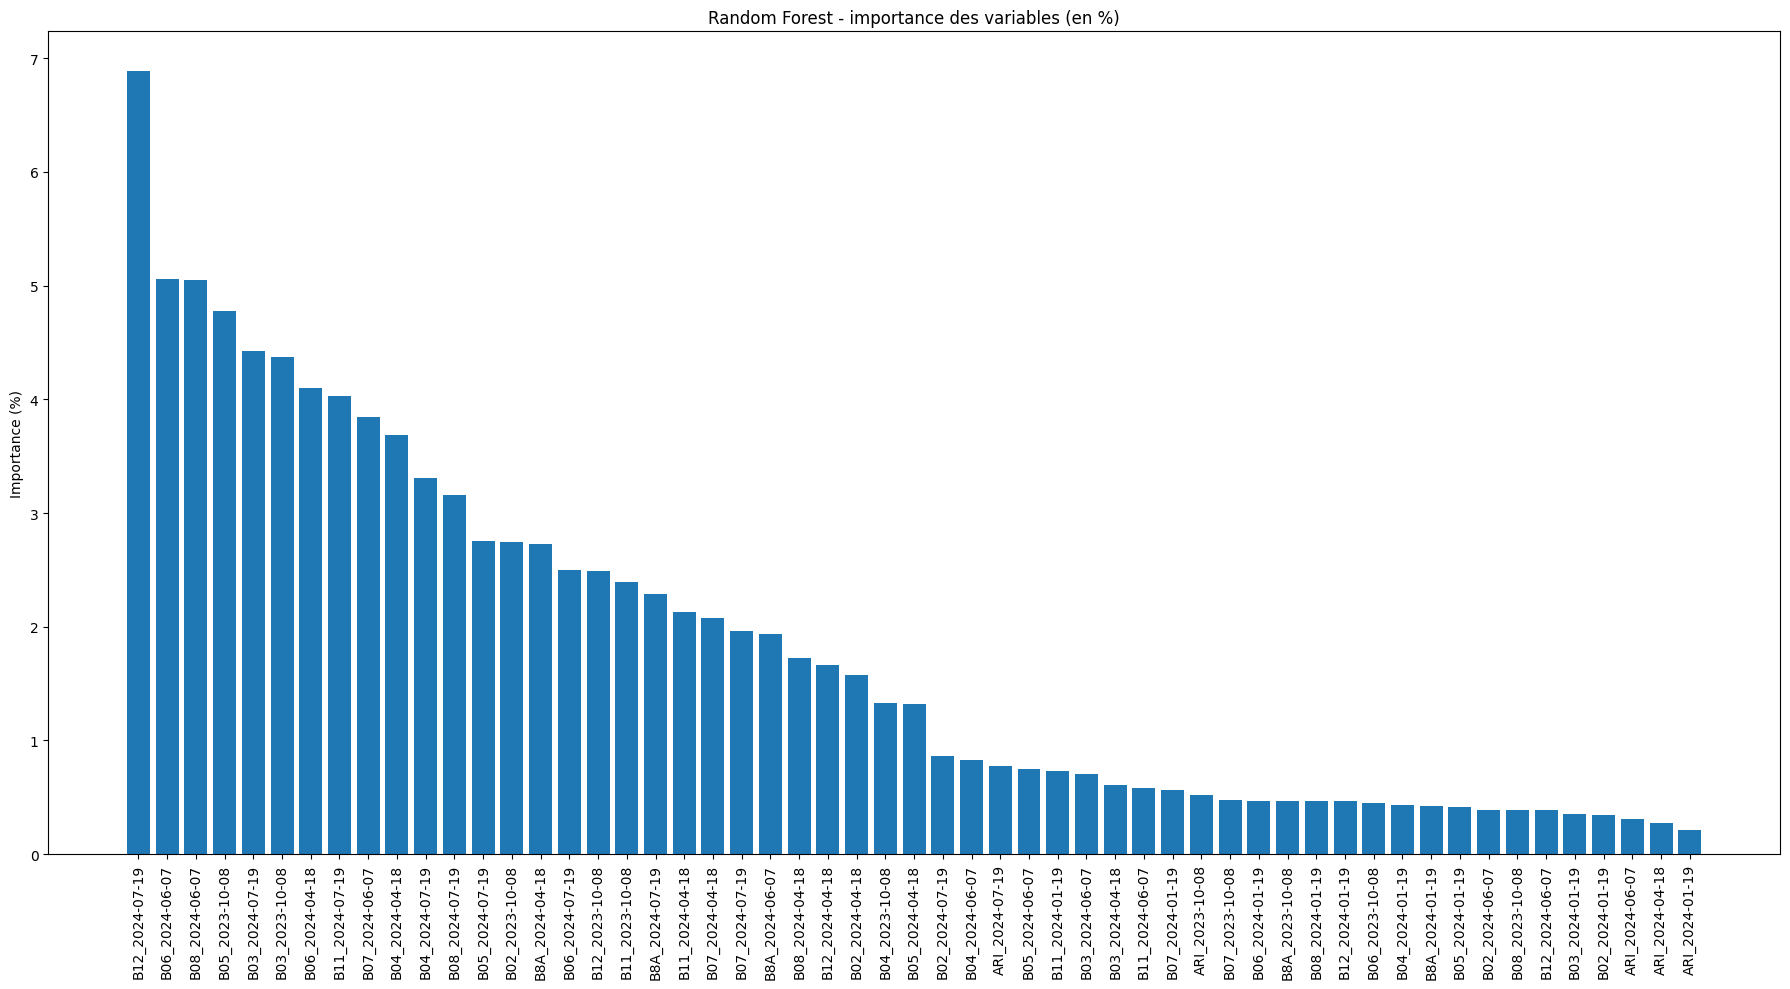

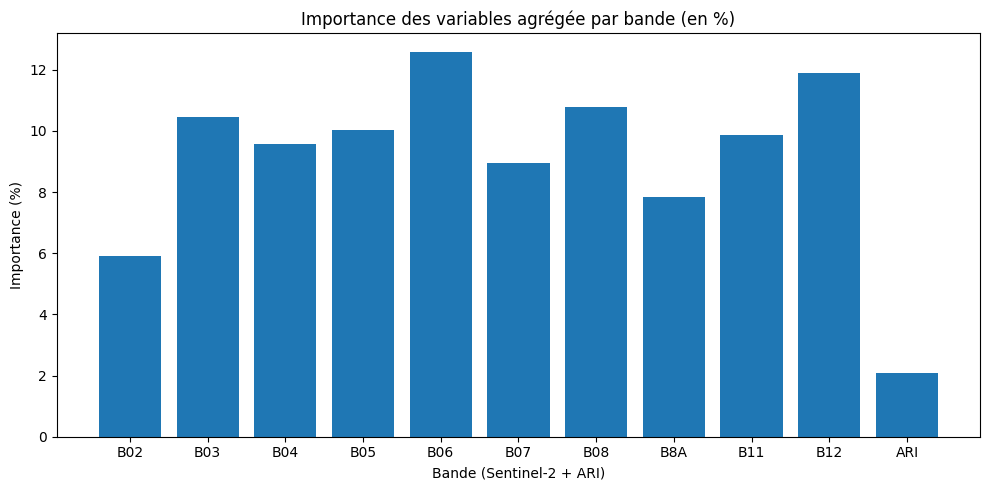

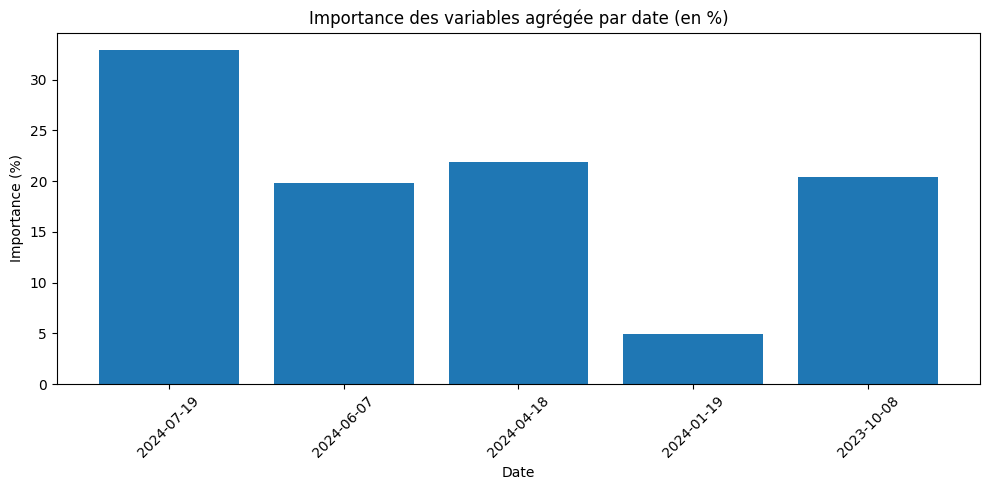

In [9]:
# ------------------------------------------------------------
# 6) Importance variables EN % (toutes / par bande / par date)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Sécurité dossier figures ---
os.makedirs(FIG, exist_ok=True)

# --- Importances RF ---
importances = best_model.feature_importances_.astype(float)
total_imp = float(np.sum(importances))
imp_pct = 100.0 * importances / total_imp  # % par variable

# --- helpers de parsing ---
def parse_feature_name(fname):
    # attend "B02_YYYY-MM-DD" ou "ARI_YYYY-MM-DD"
    band, date = fname.split("_", 1)
    return band, date

bands_s2 = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
bands_all = bands_s2 + ["ARI"]

# ============================================================
# A) Graphique: toutes les variables (55) en %
# ============================================================
order = np.argsort(imp_pct)[::-1]

plt.figure(figsize=(18, 10))
plt.bar(range(len(imp_pct)), imp_pct[order])
plt.xticks(range(len(imp_pct)), [feature_names[i] for i in order], rotation=90)
plt.ylabel("Importance (%)")
plt.title("Random Forest - importance des variables (en %)")
plt.tight_layout()
plt.show()

# ============================================================
# B) Agrégation par bande (11 barres) en %
# ============================================================
imp_by_band = {b: 0.0 for b in bands_all}

for pct, fname in zip(imp_pct, feature_names):
    band, date = parse_feature_name(fname)
    if band in imp_by_band:
        imp_by_band[band] += float(pct)

x_band = bands_all
y_band = [imp_by_band[b] for b in x_band]

plt.figure(figsize=(10, 5))
plt.bar(x_band, y_band)
plt.xlabel("Bande (Sentinel-2 + ARI)")
plt.ylabel("Importance (%)")
plt.title("Importance des variables agrégée par bande (en %)")
plt.tight_layout()
plt.show()

# ============================================================
# C) Agrégation par date (5 barres) en %
# ============================================================
imp_by_date = {d: 0.0 for d in dates}

for pct, fname in zip(imp_pct, feature_names):
    band, date = parse_feature_name(fname)
    if date in imp_by_date:
        imp_by_date[date] += float(pct)

x_date = dates
y_date = [imp_by_date[d] for d in x_date]

plt.figure(figsize=(10, 5))
plt.bar(x_date, y_date)
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Importance (%)")
plt.title("Importance des variables agrégée par date (en %)")
plt.tight_layout()
plt.show()


Le premier graphique nous indique que la bande B12 du mois de juillet et celle qui contribue le plus avec près de 7%.  
Cela peut s'expliquer par le fait que la bande B12 (SWIR) est particulièrement sensible à la teneur en eau de la végétation, un paramètre particulièrement déterminant pour différencier les végétations en été.  
  
On peut en effet voir sur le deuxième graphique que la bande B12 est la 2ème bande la plus importante (autour de 12%), juste derrière la bande B06 (Red Edge), qui est particulièrement importante car elle est sensible à la teneur en chlorophylle des végétaux, qui est un paramètre important pour les différencier.  
A l'inverse, l'importance de l'ARI est particulièrement faible (environ 2%), car elle discrimine principalement les landes (mais peu les autres classes) et uniquement à une certaine période, en automne. Egalement, l'ARI est un indice calculé à partir des bandes B03 et B05 ; ces bandes étant à déjà à la disposition de Random Forest, celle de l'ARI apporte peu d'information nouvelle.  
  
Enfin, sur le dernier graphique, on peut voir que les variables datant du mois de janvier sont clairement moins importantes que les autres dates avec environ 5%.  
Cela pourrait s'expliquer par le fait que la végétation est quasiment absente en hiver, ce qui n'aide pas pour différencier les différents types de végétation (herbes, landes et arbres).  
A l'inverse, la date qui contribue le plus est celle du mois du juillet (plus de 30%), sûrement car c'est la période de l'année la plus simple pour différencier les 3 types d'occupation du sol.  
En effet, en été les arbres sont bien développés ce qui permet de les différencier facilement des landes et des herbes. La différenciation entre ces 2 dernières classes est également plus simple en été car les herbes ont tendance à sécher voire à mourir, alors que les plantes xérophytes des landes sont plus aptes à survivre aux fortes chaleurs.  
Les 3 autres dates correspondant aux périodes du printemps et de l'automne ont quant à elles une importance modérée (environ 20%). Ces périodes de transition chez les végétaux permettent en effet de les différencier bien plus qu'en hiver, mais avec tout de même moins de précision qu'en été.

## 4. Production de la carte finale des strates

In [12]:
# ------------------------------------------------------------
# 7) Prédiction carte finale
#    FIX: prédire UNIQUEMENT sur pixels valides (ARI mask)
# ------------------------------------------------------------
n_feat = predictors_3d.shape[2]
flat = predictors_3d.reshape(-1, n_feat)

valid_flat = valid_mask.reshape(-1)
idx_valid = np.where(valid_flat)[0]

pred_flat = np.zeros(flat.shape[0], dtype=np.uint8)  # 0 = NoData

batch = 250000
for start in range(0, idx_valid.size, batch):
    sub = idx_valid[start:start+batch]
    pred_flat[sub] = best_model.predict(flat[sub]).astype(np.uint8)

pred_map = pred_flat.reshape(y, x).astype(np.uint8)
pred_map[~valid_mask] = 0  # re-force

# Ecriture GeoTiff (uint8) + NoData=0
driver = gdal.GetDriverByName("GTiff")
ds_out = driver.Create(out_map, x, y, 1, gdal.GDT_Byte, options=["COMPRESS=LZW"])
ds_out.SetGeoTransform(gt)
ds_out.SetProjection(proj)

b = ds_out.GetRasterBand(1)
b.WriteArray(pred_map)
b.SetNoDataValue(0)  # pour QGIS
b.FlushCache()
ds_out = None

## 5. Analyse des résultats et discussions

Overall Accuracy : 97.83 %


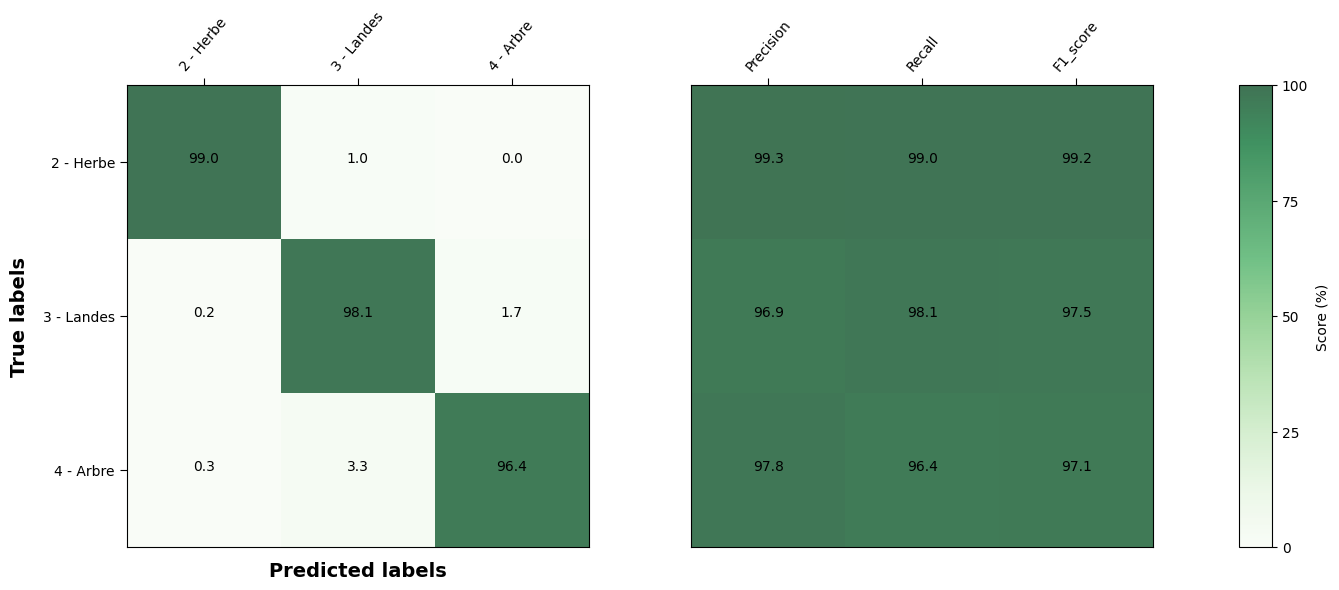

In [17]:
# ------------------------------------------------------------
# 5) Evaluation test + matrice de confusion
# ------------------------------------------------------------
y_pred = best_model.predict(X_test)

oa = accuracy_score(y_test, y_pred)
print("Overall Accuracy :", round(oa * 100, 2), "%")

# Matrice de confusion en COMPTES
cm_counts = confusion_matrix(
    y_test,
    y_pred,
    labels=ordre_classes
)

labels_txt = [f"{c} - {classe_nom[c]}" for c in ordre_classes]

plots.plot_cm(
    cm=cm_counts,
    labels=labels_txt,
    out_filename=None,   # pas d'enregistrement obligatoire
    normalize=True,      # ✅ NORMALISATION EN %
    cmap="Greens"
)

Avec 97,83 %, la précision globale du modèle semble très bonne.  
Si on regarde la matrice de confusion, on peut voir que le F1-score (qui combine précision et rappel) est de plus de 99% pour la classe Herbe, et d'environ 97% pour les classes Landes et Arbre, ce qui montre bien que le modèle a réussi à classer avec précision toutes les classes.  
Cependant, si on regarde plus en détail, on peut voir que la plus grande confusion se situe entre la classe Landes et la classe Arbre, avec notamment 3.3% d'arbres classés en landes.  
Cette confusion peut s'expliquer par la relative similitude entre les arbres, et les buissons que l'on retrouve dans les landes.  
Cette confusion explique également le F1-score relativement plus haut de la classe Herbe, qui est une formation végétale qui se confond moins avec les arbres et les landes.